# 02 · Reversibility — leapfrog stack, same batch

**ERA V5 · Reversibility assignment**, part 2 of 3.

A reversible network doesn't *store* activations — it **rebuilds** them during the backward pass by running the layer update in reverse. Following Gal, Eliasof, Turek, Ascher, Treister & Haber, *Reversing Large Language Models for Efficient Training and Fine-Tuning* (Nov 2025), we use the **leapfrog / midpoint** rule:

$$p_{\ell+1} = p_{\ell-1} + 2h\,f_{\theta_\ell}(p_\ell)\qquad\text{(forward)}$$
$$p_{\ell-1} = p_{\ell+1} - 2h\,f_{\theta_\ell}(p_\ell)\qquad\text{(reverse)}$$

Because layer $\ell$ is evaluated at $p_\ell$ — the state the backward pass already holds — the step runs both ways. The forward keeps only the two boundary states; activation memory becomes **independent of depth**.

In [1]:
import os, sys, json
# make the revllm package importable whether run from repo root or notebooks/
REPO = None
for p in [os.getcwd(), os.path.dirname(os.getcwd())]:
    if os.path.exists(os.path.join(p, "revllm")):
        REPO = p
        if p not in sys.path:
            sys.path.insert(0, p)
        break
assert REPO, "could not locate the revllm package"
RESULTS = os.path.join(REPO, "results")
import torch
from revllm.engine import get_device
DEVICE = get_device()
print("repo:", REPO, "| device:", DEVICE, "| torch:", torch.__version__)

repo: /Users/sokorada/Documents/ERA_V5/DistributedTraining_2 | device: mps | torch: 2.13.0


## Which integrator is actually reversible? (euler vs leapfrog)
A plain residual / Euler step `p_{l+1}=p_l+h·f(p_l)` **cannot** be reversed: recovering `p_l` would need `f(p_l)`, computed from the very state we're trying to recover. Leapfrog evaluates the block at the *held* state, so it reverses exactly. We measure the relative error of the input rebuilt by running the stack backwards.

In [2]:
import torch
from revllm.model import Block, GPTConfig
from revllm.reversible import reconstruction_error
torch.manual_seed(0)
bcfg = GPTConfig(n_layer=9, n_embd=256, n_head=8, dropout=0.0)
blocks = torch.nn.ModuleList([Block(bcfg) for _ in range(bcfg.n_layer)])
x = torch.randn(4, 128, bcfg.n_embd)
print(f"{'h':>5} {'leapfrog':>12} {'euler(naive)':>14}")
for h in [0.1, 0.25, 0.5, 1.0]:
    e_lf,_ = reconstruction_error(x, blocks, h, 'leapfrog')
    e_eu,_ = reconstruction_error(x, blocks, h, 'euler')
    print(f'{h:>5} {e_lf:>12.2e} {e_eu:>14.2e}')

    h     leapfrog   euler(naive)
  0.1     6.75e-08       1.84e-03
 0.25     1.28e-07       1.17e-02
  0.5     2.65e-07       4.90e-02


  1.0     7.00e-07       2.32e-01


**Verdict:** leapfrog/midpoint reconstructs to ~1e-7 at every step size; naive euler is not reversible and its error grows with `h`. **Leapfrog is the variant that works** — it is what we train with.

## The memory-free backward is correct
The custom autograd `Function` reconstructs states and propagates the leapfrog adjoint. We check its gradients against an ordinary-autograd reference that computes the identical recurrence while *storing* activations.

In [3]:
import copy, torch
from revllm.reversible import reversible_stack, leapfrog_reference
torch.manual_seed(0)
cfg = GPTConfig(n_layer=6, n_embd=64, n_head=4, dropout=0.0)
ba = torch.nn.ModuleList([Block(cfg) for _ in range(cfg.n_layer)]); bb = copy.deepcopy(ba)
x1 = torch.randn(2,16,cfg.n_embd, requires_grad=True); x2 = x1.detach().clone().requires_grad_(True)
out_ref = leapfrog_reference(x2, bb, 0.5); (out_ref**2).mean().backward()
out = reversible_stack(x1, ba, 0.5); (out**2).mean().backward()
print('outputs match      :', torch.allclose(out, out_ref, atol=1e-5))
print('grad_x max abs diff:', (x1.grad-x2.grad).abs().max().item())
gd = max((pa.grad-pb.grad).abs().max().item() for pa,pb in zip(ba.parameters(), bb.parameters()))
print('param grad max diff:', gd)

outputs match      : True
grad_x max abs diff: 1.4551915228366852e-09
param grad max diff: 5.587935447692871e-09


Gradients match to ~1e-9 (float32 machine precision), while the reversible path never stored the intermediate activations.

## Short live demo — reversible training

In [4]:
from revllm.engine import train_run
from revllm.data import prepare
train_bin, val_bin = prepare()
rcfg = GPTConfig(n_layer=9, n_embd=256, n_head=8, block_size=512,
                 mode='reversible', integrator='leapfrog', step_size=0.5)
demo = train_run(rcfg, name='demo_rev', batch_size=32, token_budget=300_000,
                 train_bin=train_bin, val_bin=val_bin, device=DEVICE, log_every=5)
print(demo.summary())

[data] cached: /Users/sokorada/Documents/ERA_V5/DistributedTraining_2/data/train.bin, /Users/sokorada/Documents/ERA_V5/DistributedTraining_2/data/val.bin


[demo_rev] step     0/18  loss 10.8569  7,636 tok/s  peak 15.75GB


[demo_rev] step     5/18  loss 9.9574  8,858 tok/s  peak 15.75GB


[demo_rev] step    10/18  loss 9.1097  9,040 tok/s  peak 15.75GB


[demo_rev] step    15/18  loss 8.2095  8,942 tok/s  peak 15.75GB


[demo_rev] step    17/18  loss 8.0811  8,881 tok/s  peak 15.75GB


demo_rev: params=20.11M  bs=32  tok/step=16,384  final_val_loss=8.0741  speed=8,881 tok/s  peak_mem=15.755 GB


## Full run vs baseline — same batch (32), 50M tokens
Reversibility should reach ~the same loss (the math is equivalent) while using less memory.

In [5]:
base = json.load(open(os.path.join(RESULTS,'01_baseline.json')))
rev  = json.load(open(os.path.join(RESULTS,'02_reversible.json')))
def row(r): return (r['final_val_loss'], r['tokens_per_sec'], r['peak_mem_bytes']/1e9)
print(f"{'run':<26}{'val loss':>10}{'tok/s':>12}{'peak GB':>10}")
for name,r in [('baseline (standard)',base),('reversible (leapfrog)',rev)]:
    vl,tp,gb = row(r); print(f'{name:<26}{vl:>10.4f}{tp:>12,.0f}{gb:>10.2f}')
print(f"\nmemory saved at bs=32: {base['peak_mem_bytes']/rev['peak_mem_bytes']:.2f}x")

run                         val loss       tok/s   peak GB
baseline (standard)           2.0149      11,383     20.06
reversible (leapfrog)         2.0656       8,277     15.75

memory saved at bs=32: 1.27x


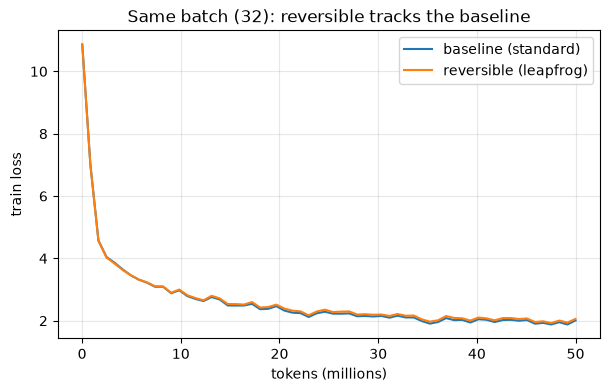

In [6]:
import matplotlib.pyplot as plt
plt.figure(figsize=(7,4))
for r,lab in [(base,'baseline (standard)'),(rev,'reversible (leapfrog)')]:
    h=r['loss_history']; plt.plot([x['tokens']/1e6 for x in h],[x['train_loss'] for x in h],label=lab)
plt.xlabel('tokens (millions)'); plt.ylabel('train loss'); plt.legend(); plt.grid(alpha=0.3)
plt.title('Same batch (32): reversible tracks the baseline'); plt.show()

➡️ Continue to **03 · Max batch**, where the memory saved is spent on the largest batch that fits.